#  K-Means Clustering
El **K-Means** es un algoritmo de **aprendizaje no supervisado**, lo que significa que **no necesita etiquetas** ni categorías predefinidas.  
Su trabajo es más bien de **descubrir patrones ocultos y agrupa datos parecidos** sin que nadie le diga cómo deberían organizarse.

---
### ¿Qué hace K-Means?

1. El algoritmo elige aleatoriamente **K puntos** (llamados *centroides*).  
2. Asigna cada dato al centro más cercano → creando **K grupos o clusters**.  
3. Calcula nuevos centroides (el promedio de cada grupo).  
4. Repite el proceso hasta que los grupos se estabilicen (ya no cambian mucho).

### Ejemplo práctico: Top 5 jugadores de las mejores ligas

Vamos a usar una pequeña base de datos con los **5 mejores jugadores** de distintas ligas (por ejemplo, Premier League, LaLiga, Serie A, Bundesliga y Ligue 1).



In [1]:
#Importar librerías necesarias
import pandas as pd                     # Para manejar los datos en formato tabla (DataFrames)
import matplotlib.pyplot as plt          # Para crear gráficos estáticos (como el del método del codo)
import plotly.express as px              # Para gráficos interactivos (aunque no se usa en este ejemplo)
from sklearn.preprocessing import StandardScaler  # Para escalar los datos numéricos antes del clustering
from sklearn.cluster import KMeans       # Algoritmo de agrupamiento no supervisado (K-Means)

In [2]:
#Carga de dataframe
df = pd.read_csv("C:/Users/Willi/Downloads/top5_leagues_player.csv", sep=',')
df.head(5)

,Unnamed: 0,name,full_name,age,height,nationality,place_of_birth,price,max_price,position,shirt_nr,foot,club,contract_expires,joined_club,player_agent,outfitter,league
0,0,Ederson,NaN,29,1.88,Brazil Portugal,Osasco (SP),45.00,70.0,Goalkeeper,31,left,Man City,2026-06-30,2017-07-01,Gestifute,Puma,EPL
1,1,Stefan Ortega,Stefan Ortega Moreno,30,1.85,Germany Spain,Hofgeismar,6.00,6.0,Goalkeeper,18,right,Man City,2025-06-30,2022-07-01,neblung ...,NaN,EPL
2,2,Scott Carson,Scott Paul Carson,37,1.88,England,Whitehaven,0.25,6.0,Goalkeeper,33,right,Man City,2023-06-30,2021-07-20,Wasserman,Puma,EPL
3,3,Rúben Dias,Rúben Santos Gato Alves Dias,26,1.87,Portugal,Amadora,75.00,75.0,Defender - Centre-Back,3,right,Man City,2027-06-30,2020-09-29,Gestifute,Nike,EPL
4,4,Nathan Aké,Nathan Benjamin Aké,28,1.80,Netherlands Cote d'Ivoire,Den Haag,35.00,40.0,Defender - Centre-Back,6,left,Man City,2025-06-30,2020-08-05,Wasserman,Nike,EPL


In [7]:
# Seleccionamos las columnas relevantes
# Nos quedamos solo con las columnas que usaremos en el análisis (edad, altura y precios)
df_kmeans = df[['age', 'height', 'price', 'max_price']].dropna()
df_kmeans.head(6)

,age,height,price,max_price
0,29,1.88,45.00,70.0
1,30,1.85,6.00,6.0
2,37,1.88,0.25,6.0
3,26,1.87,75.00,75.0
4,28,1.80,35.00,40.0
5,28,1.88,30.00,60.0


## Estandarizar los datos numéricos, es decir:

Le resta a cada valor la media de su columna.
Luego lo divide entre la desviación estándar de esa columna.
Resultado: cada columna termina con media = 0 y desviación estándar = 1.
Esto es muy útil en algoritmos como K-Means, porque estos se basan en distancias — y si una variable tiene valores grandes, puede dominar a las demás injustamente.

In [8]:
scaler = StandardScaler()               # Creamos el objeto que normaliza los datos (media=0, desviación=1)
X_scaled = scaler.fit_transform(df_kmeans)  # Escalamos las columnas seleccionadas
df_kmeans.head(6)                       # (Solo muestra los datos originales; X_scaled es el escalado real)

,age,height,price,max_price
0,29,1.88,45.00,70.0
1,30,1.85,6.00,6.0
2,37,1.88,0.25,6.0
3,26,1.87,75.00,75.0
4,28,1.80,35.00,40.0
5,28,1.88,30.00,60.0


## Método del Codo (Elbow Method)

Cuando usamos **K-Means**, tenemos que elegir cuántos grupos (**K**) queremos formar.  
Pero… ¿cómo saber el número ideal de clusters? 
En ese gráfico, la curva **va bajando rápidamente al inicio**, pero luego se **“dobla” como un codo**:  
ese punto donde deja de mejorar mucho es el **K óptimo**.

En resumen:
> Buscamos el punto donde agregar más grupos **ya no aporta gran mejora**.  
> Si lo ves en el gráfico y parece un codo… ese es el número mágico.

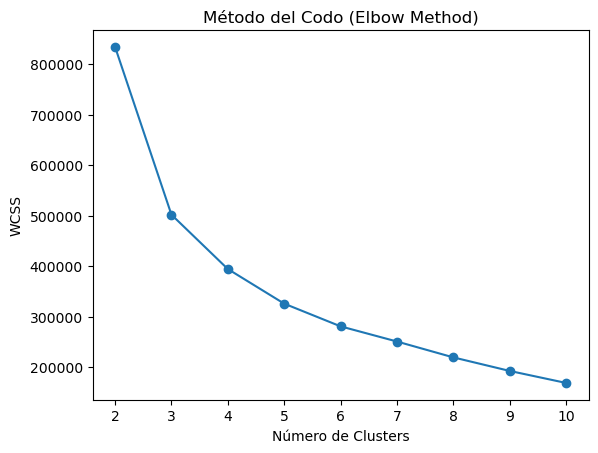

In [10]:
# calcular cuantos cluster hacer con el metodo de elbow
wcss = [] # Lista vacía donde se guardará la "inercia" (distancia dentro de cada cluster)
for i in range(2, 11): 
# Probamos con diferentes números de clusters (del 2 al 10)
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0) # Cuántas veces probar con diferentes centroides para mayor estabilidad
    kmeans.fit(df_kmeans)
    wcss.append(kmeans.inertia_)
    
# Graficar el método del codo
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS') 
plt.show()

In [11]:
# Elegimos 4 clusters según el codo
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
# Ajustamos el modelo a los datos escalados y asignamos el cluster correspondiente a cada jugador.
df_kmeans["cluster"] = kmeans.fit_predict(X_scaled)

In [12]:
cluster_summary = df_kmeans.groupby('cluster').mean()  # Promedio de cada variable por grupo
print("📊 Resumen de clusters:\n", cluster_summary, "\n")  # Mostramos resumen numérico

📊 Resumen de clusters:
                age    height      price  max_price
cluster                                           
0        23.085016  1.868767   6.981376   8.931668
1        31.620548  1.857740   4.933425  14.866815
2        26.104072  1.827919  50.334842  70.855204
3        25.339056  1.752461   9.152146  14.330079 



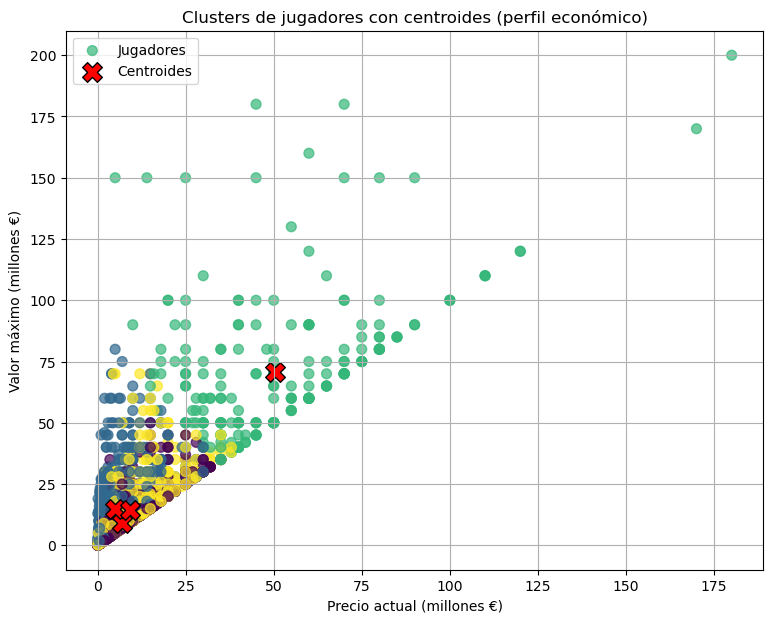

In [13]:
centroids_scaled = kmeans.cluster_centers_             # Centroides en escala estandarizada
centroids = scaler.inverse_transform(centroids_scaled) # Los devolvemos a sus valores originales (edad, precio, etc.)

# Gráfico con centroides
plt.figure(figsize=(9,7))

# Dibujar los puntos de jugadores, coloreados por cluster
plt.scatter(df_kmeans['price'], df_kmeans['max_price'], 
            c=df_kmeans['cluster'], cmap='viridis', alpha=0.7, s=50, label='Jugadores')

# Dibujar los centroides (con forma de X y tamaño mayor)
plt.scatter(centroids[:, 2], centroids[:, 3], 
            c='red', marker='X', s=200, edgecolor='black', label='Centroides')

# Etiquetas y títulos
plt.xlabel('Precio actual (millones €)')
plt.ylabel('Valor máximo (millones €)')
plt.title('Clusters de jugadores con centroides (perfil económico)')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Combinamos la información original de los jugadores (nombre, posición y club)
# con su cluster correspondiente para poder analizar ejemplos reales de cada grupo.
df_clusters = pd.concat([df[['name', 'position', 'club']], df_kmeans['cluster']], axis=1)

# Imprimimos algunos ejemplos de jugadores de cada cluster.
print("**Ejemplo de jugadores por cluster:**")
for c in sorted(df_kmeans['cluster'].unique()):
    print(f"\nCluster {c} - ejemplos:")
    print(df_clusters[df_clusters['cluster'] == c].head(5))

**Ejemplo de jugadores por cluster:**

Cluster 0 - ejemplos:
               name                       position         club  cluster
18      Cole Palmer  midfield - Attacking Midfield     Man City      0.0
26  Gabriel Slonina                     Goalkeeper      Chelsea      0.0
31  Trevoh Chalobah         Defender - Centre-Back      Chelsea      0.0
35       Lewis Hall           Defender - Left-Back  Chelsea U21      0.0
40    Denis Zakaria  midfield - Defensive Midfield      Chelsea      0.0

Cluster 1 - ejemplos:
              name                     position      club  cluster
1    Stefan Ortega                   Goalkeeper  Man City      1.0
2     Scott Carson                   Goalkeeper  Man City      1.0
10     Kyle Walker        Defender - Right-Back  Man City      1.0
15  Ilkay Gündogan  midfield - Central Midfield  Man City      1.0
24   Edouard Mendy                   Goalkeeper   Chelsea      1.0

Cluster 2 - ejemplos:
              name                position      club 

# K-Nearest Neighbors (KNN)

El **KNN** es un algoritmo de **aprendizaje supervisado**, lo que significa que **aprende a partir de ejemplos ya clasificados**.  
Cuando recibe un nuevo dato, busca los **K datos más parecidos (sus vecinos más cercanos)** y decide la clase según la mayoría.

---

### ⚙️ ¿Qué hace KNN?

1. Calcula la **distancia** entre el nuevo punto y todos los puntos del conjunto de entrenamiento.  
2. Selecciona los **K vecinos más cercanos**.  
3. Observa la **clase** de esos vecinos.  
4. Asigna al nuevo dato la **clase más común** entre ellos.

En pocas palabras:  
> KNN no genera fórmulas ni modelos matemáticos; simplemente **clasifica comparando similitudes**.  
Es fácil de entender, pero poderoso cuando los datos están bien preparados.

In [19]:
from sklearn.model_selection import train_test_split      # Separar datos en entrenamiento y prueba
from sklearn.neighbors import KNeighborsClassifier        # Modelo KNN
from sklearn.preprocessing import StandardScaler          # Escalador (opcional)
import pandas as pd                                       # Manejo de DataFrames
import numpy as np                                        # Operaciones numéricas

In [20]:
# Definimos variables predictoras y objetivo
# 'X' contiene las variables que usaremos para predecir el cluster
X = df_kmeans[['age', 'height', 'price', 'max_price']]
# 'y' es la variable objetivo: el cluster asignado por K-Means
y = df_kmeans['cluster']

## test_size=0.2 → el 20% de los datos se usa para prueba
## random_state=42 → asegura que la división sea siempre la misma
test_size Si se cambia a 0.3 o 0.4, tendrias menos datos para entrenar y más para evaluar. Si se baja a 0.1, entrenas más fuerte, pero pruebas menos.
random_state=42	Fija una semilla aleatoria para que la división sea reproducible (siempre igual).	Si se cambias o lo quitamos, cada vez que se ejecute el código los datos se dividirán de forma distinta.

In [22]:
#División del dataset en entrenamiento y prueba
# -----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# Entrenamiento del modelo 
# Usamos K=4 vecinos cercanos
knn = KNeighborsClassifier(n_neighbors=4)
# Entrenamos el modelo (X_train → características, y_train → etiquetas)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4)

In [30]:
# Evaluación del modelo
# Evalúa qué porcentaje de las predicciones del modelo son correctas
accuracy = knn.score(X_test, y_test)
# Mostramos el resultado en porcentaje
print(f"Precisión del modelo: {accuracy*100:.2f}%")

Precisión del modelo: 72.06%


In [38]:
# Agrupamos los datos por cluster para entender el perfil medio de cada grupo
resumen_clusters = df_kmeans.groupby('cluster')[['age', 'height', 'price', 'max_price']].mean().round(2)
# Mostramos la tabla con resumen
print("Perfil promedio de cada cluster:\n")
print(resumen_clusters)

Perfil promedio de cada cluster:

           age  height  price  max_price
cluster                                 
0        23.09    1.87   6.98       8.93
1        31.62    1.86   4.93      14.87
2        26.10    1.83  50.33      70.86
3        25.34    1.75   9.15      14.33


## Interpretación
Con cada clusters definido, podemos "clasificar" los resultados para hallar nuestro jugador 

In [39]:
interpretaciones = {
    0: "Jugadores jovenes",
    1: "Veterano valioso",
    2: "Estrella de élite",
    3: "Jugador de rotación o promesa"
}

In [41]:
# Creamos un DataFrame con el perfil del jugador a buscar
# Ejemplo: 24 años, altura promedio (1.80 m), precio 30M, precio máximo 50M
nuevo_jugador = pd.DataFrame({
    'age': [30],
    'height': [1.80],
    'price': [10],
    'max_price': [50]
})

# Usamos el modelo entrenado para predecir el cluster de ese jugador
prediccion_cluster = knn.predict(nuevo_jugador)[0]
# Mostramos el resultado interpretado
print(f"El jugador con perfil dado pertenece al cluster: {prediccion_cluster} ({interpretaciones[prediccion_cluster]})")


El jugador con perfil dado pertenece al cluster: 1 (Veterano valioso)


In [43]:
# Buscamos jugadores similares en el dataset original
# Filtramos los jugadores que pertenezcan al mismo cluster
jugadores_similares = df_clusters[df_clusters['cluster'] == prediccion_cluster]
# Mostramos algunos ejemplos
print("Jugadores similares encontrados:")
print(jugadores_similares.head(10))

Jugadores similares encontrados:
                 name                     position      club  cluster
1       Stefan Ortega                   Goalkeeper  Man City      1.0
2        Scott Carson                   Goalkeeper  Man City      1.0
10        Kyle Walker        Defender - Right-Back  Man City      1.0
15     Ilkay Gündogan  midfield - Central Midfield  Man City      1.0
24      Edouard Mendy                   Goalkeeper   Chelsea      1.0
25  Kepa Arrizabalaga                   Goalkeeper   Chelsea      1.0
27  Marcus Bettinelli                   Goalkeeper   Chelsea      1.0
32       Thiago Silva       Defender - Centre-Back   Chelsea      1.0
37  César Azpilicueta        Defender - Right-Back   Chelsea      1.0
51       Hakim Ziyech        Attack - Right Winger   Chelsea      1.0
